## Phần 1: Import thư viện và thiết lập môi trường

**Mục tiêu:**

Phần này thực hiện nhập các thư viện cần thiết phục vụ cho toàn bộ quy trình xử lý:

* **Xử lý dữ liệu:** Sử dụng `pandas` và `numpy`.
* **Trực quan hóa:** Sử dụng `matplotlib` và `seaborn`.
* **Tiền xử lý & Mô hình hóa:** Sử dụng `sklearn` và thư viện `re` để xử lý chuỗi.
* **Cấu hình:** Bỏ qua các cảnh báo không cần thiết bằng `warnings`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from sklearn import impute
warnings.filterwarnings("ignore")

## Phần 2: Tải và khám phá dữ liệu ban đầu

### 2.1. Đọc tập dữ liệu

* Tập dữ liệu bất động sản được lưu dưới định dạng **JSON**.
* Dữ liệu được tải từ **Google Drive** vào môi trường làm việc thông qua lệnh `drive.mount()`.

### 2.2. Khám phá sơ bộ cấu trúc dữ liệu

Thực hiện các bước kiểm tra cơ bản để hiểu dữ liệu:

* **Kích thước:** Kiểm tra số lượng dòng và cột của `df` bằng `df.shape`.
* **Dữ liệu mẫu:** Quan sát các bản ghi đầu tiên bằng `df.head()`.
* **Đặc trưng:** Xem xét các giá trị độc nhất trong các cột như `law`, `direction`, `price`.
* **Kiểu dữ liệu:** Nhận diện các cột đang ở dạng chuỗi (`object`) cần chuyển đổi.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_json('/content/drive/MyDrive/Colab Notebooks/Khai pha DL TLU/Cuối kỳ/Data btl datamining/data.json')
df.head()

,_id,price,description,address,area,start_date,end_date,floor_number,bedroom_number,is_dinning_room,is_kitchen,is_terrace,is_car_pack,is_owner,type,direction,street_in_front_of_house,width,height,law
0,{'$oid': '61ab963ae2434d9b2bf85176'},"5,4 tỷ",+ Cần bán gấp đất MINH KHAI.\r\n+ Diện tích 70...,"Đường Minh Khai, Phường Minh Khai, Quận Hai B...",70 m,Ngày đăng: 03/12/2021,NaN,4,3,False,False,False,False,False,Nhà trong hẻm,_,3m,"7,7m","9,5m",Sổ hồng/ Sổ đỏ
1,{'$oid': '61ab963ae2434d9b2bf85177'},"4,45 tỷ","- Vị trí cự kỳ trắc địa, trung tâm dân cư trí ...","Đường Lê Trọng Tấn, Phường Sơn Kỳ, Quận Tân P...",64 m,Ngày đăng: 03/12/2021,NaN,4,4,True,True,True,True,False,Nhà mặt tiền,_,7m,4m,16m,---
2,{'$oid': '61ab963ae2434d9b2bf85178'},"5,6 tỷ",nhà phố 200m2 - 4 tầng chỉ 5 căn đẹp nhất (mặt...,"Đường An Phú Đông 1, Phường An Phú Đông, Quận...",64 m,Ngày đăng: 03/12/2021,NaN,4,4,True,True,True,True,False,Nhà mặt tiền,_,12m,"4,5m",15m,Sổ hồng/ Sổ đỏ
3,{'$oid': '61ab963ae2434d9b2bf85179'},"1,5 tỷ","- Giá đã gồm bao sang tên, Nhà chính chủ đứng ...","Đường Lê Trọng Tấn, Phường Yên Nghĩa, Quận Hà...",31 m,Ngày đăng: 03/12/2021,NaN,3,3,False,False,False,False,False,Nhà mặt tiền,Đông Nam,3m,4m,8m,Sổ hồng/ Sổ đỏ
4,{'$oid': '61ab963ae2434d9b2bf8517a'},"1,12 tỷ",Chính chủ tên sổ đỏ cần bán\r\nNhà xây 3 tầng ...,"Đường Biên Giang, Phường Biên Giang, Quận Hà ...",30 m,Ngày đăng: 03/12/2021,NaN,3,3,False,False,False,False,False,Nhà trong hẻm,Đông Nam,3m,4m,8m,Sổ hồng/ Sổ đỏ


In [4]:
df.shape

(75636, 20)

In [5]:
df['description'][0]

'+ Cần bán gấp đất MINH KHAI.\r\n+ Diện tích 70m, mặt tiền 7,7m. Trên đất đã xây nhà 4 tầng + 1 nhà cấp 4 trước nhà có 25M Sân riêng đi khóa về mở. Mảnh đất thuộc ngõ rộng ô tô vào thoải mái. Xung quanh đầy đủ tiện ích, TTTM, gần Times City, tiện giao thông, an ninh tốt. các trường ĐH lớn. Phù hợp với mọi loại hình đầu tư chia lô xây bán, xây CCMN...\r\n+ Sổ đỏ chính chủ vuông đẹp.\r\n+ Giá 5.4 tỷ.'

In [6]:
df['law'].unique()

array(['Sổ hồng/ Sổ đỏ', '---', 'Giấy tờ hợp lệ', 'Giấy phép KD',
       'Giấy phép XD'], dtype=object)

In [7]:
df['area']

,area
0,70 m
1,64 m
2,64 m
3,31 m
4,30 m
...,...
75631,50 m
75632,43 m
75633,80 m
75634,75 m


In [8]:
df['direction'].unique()

array(['_', 'Đông Nam', 'Tây Bắc', 'Nam', 'Tây Nam', 'Đông Bắc', 'Bắc',
       'Tây', 'Đông'], dtype=object)

In [9]:
df['price'].unique()

array([' 5,4 tỷ ', ' 4,45 tỷ ', ' 5,6 tỷ ', ..., ' 3,84 tỷ ', ' 43,3 tỷ ',
       ' 185 tỷ 4 ngàn '], dtype=object)

In [10]:
df['address'][0]

' Đường Minh Khai, Phường Minh Khai, Quận Hai Bà Trưng, Hà Nội'

In [11]:
df['bedroom_number'].unique()

array(['3', '4', '5', '8', '2', '6', '9', '1', '14', '---', '12', '7',
       '21', '40', '31', '10', '15', '28', '20', '22', '52', '13', '46',
       '11', '54', '16', '44', '35', '85', '25', '68', '70', '36', '50',
       '30', '56', '27', '100', '39', '60', '18', '42', '17', '24', '45',
       '23', '75', '29', '71', '33', '19', '26', '90', '43', '58', '38',
       '32', '234', '37', '91', '80', '268', '48', '145', '65', '34',
       '115', '180', '66', '110', '79', '95', '92', '67', '235', '47',
       '77', '400', '57', '106', '73', '102', '166', '266', '160', '86',
       '424', '300', '88', '356', '55', '78', '41', '51', '49', '111'],
      dtype=object)

In [12]:
df['floor_number'].unique()

array(['4', '3', '9', '5', '2', '8', '6', '1', '---', '7', '14', '11',
       '15', '10', '20', '17', '13', '12', '18', '23', '31', '21', '16',
       '24', '25', '55', '57', '88', '45', '22', '26', '44', '30', '75',
       '46', '43', '35', '111', '32', '33', '40', '761', '101', '59'],
      dtype=object)

In [13]:
df['type'].unique()

array(['Nhà trong hẻm', 'Nhà mặt tiền'], dtype=object)

## Phần 3: Khám phá dữ liệu (EDA) tổng quan

### 3.1. Kiểm tra thông tin định dạng

Sử dụng phương thức `df.info()` để thực hiện:

* Kiểm tra **kiểu dữ liệu** của từng cột.
* Thống kê số lượng **giá trị thiếu** (`non-null count`).
* Xác định các cột tiềm năng cần thực hiện **ép kiểu**.

### 3.2. Loại bỏ các thuộc tính không cần thiết

Loại bỏ các cột không mang lại giá trị dự báo hoặc chứa quá nhiều nhiễu:

* Các cột bị loại bỏ: `description`, `_id`, `start_date`, `end_date`.
* Mục tiêu: **Giảm nhiễu** dữ liệu và tối ưu hóa hiệu quả huấn luyện.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75636 entries, 0 to 75635
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   _id                       75636 non-null  object 
 1   price                     75636 non-null  object 
 2   description               75386 non-null  object 
 3   address                   75636 non-null  object 
 4   area                      75636 non-null  object 
 5   start_date                75636 non-null  object 
 6   end_date                  0 non-null      float64
 7   floor_number              75636 non-null  object 
 8   bedroom_number            75636 non-null  object 
 9   is_dinning_room           75636 non-null  bool   
 10  is_kitchen                75636 non-null  bool   
 11  is_terrace                75636 non-null  bool   
 12  is_car_pack               75636 non-null  bool   
 13  is_owner                  75636 non-null  bool   
 14  type  

In [15]:
# xử lý các cột không mang nhiều thông tin
df.drop(['description','_id', 'start_date', 'end_date'], inplace=True, axis =1)
df.columns

Index(['price', 'address', 'area', 'floor_number', 'bedroom_number',
       'is_dinning_room', 'is_kitchen', 'is_terrace', 'is_car_pack',
       'is_owner', 'type', 'direction', 'street_in_front_of_house', 'width',
       'height', 'law'],
      dtype='object')

## Phần 4: Tiền xử lý dữ liệu (Data Preprocessing)

**Vấn đề của dữ liệu thô:**

* Kiểu dữ liệu không đồng nhất.
* Các giá trị số quan trọng (`price`, `area`) đang ở dạng **chuỗi ký tự**.
* Chứa các **đơn vị đo lường** (tỷ, m2, m) và ký tự đặc biệt.

Quy trình chuẩn hóa sẽ đưa dữ liệu về định dạng **Numeric** để mô hình có thể tính toán.

### 4.1. Phân tích các lỗi định dạng

Các thuộc tính số cần được tách khỏi đơn vị đo lường và chuyển đổi dấu ngăn cách thập phân:

* Ví dụ: `"5,4 tỷ"` cần chuyển thành `5.4`.
* Ví dụ: `"70 m"` cần chuyển thành `70.0`.
* Ví dụ: `"7,7m"` cần chuyển thành `7.7`.

### 4.2. Chuẩn hóa thuộc tính diện tích

* Sử dụng hàm `process_area()` để xử lý cột `area`.
* Thay thế dấu `,` bằng `.` và loại bỏ ký tự `m`.
* Chuyển đổi toàn bộ sang kiểu `float`, các giá trị lỗi được gán là `np.nan`.

In [16]:
def process_area(area):

    for i in range(len(area)):

        try:
            value = area[i].replace("m", "").replace(",", ".").strip()
            area[i] = float(value)

        except:
            area[i] = np.nan

    return area


### 4.3. Chuẩn hóa thuộc tính hướng nhà

* Xử lý cột `direction` để đồng nhất định dạng.
* Chuyển các ký tự đại diện cho dữ liệu thiếu như `"_"` về giá trị chuẩn `np.nan`.

In [17]:
def process_direction(direction):

    for i in range(len(direction)):

        if direction[i] == "_":
            direction[i] = np.nan

    return direction


### 4.4. Chuẩn hóa thuộc tính pháp lý

* Xử lý cột `law` nhằm giảm sự không đồng nhất.
* Các giá trị không xác định như `"---"` sẽ được quy đổi về `np.nan`.

In [18]:
def process_law(law):

    for i in range(len(law)):

        if law[i] == "---":
            law[i] = np.nan

    return law

### 4.5. Chuẩn hóa giá nhà

* Chuyển đổi cột `price` về đơn vị chuẩn là **tỷ đồng**.
* Loại bỏ chữ `tỷ`, xử lý dấu ngăn cách và ép kiểu về `float`.

In [19]:
def process_price(price, area):

    for i in range(len(price)):

        try:
            value = price[i].replace("tỷ", "").replace(",", ".").strip()
            price[i] = float(value)

        except:
            price[i] = np.nan

    return price

### 4.6. Tách thông tin địa chỉ chi tiết

* Hàm `process_address()` thực hiện bóc tách chuỗi `address`.
* Tạo ra hai đặc trưng mới là `district` (Quận/Huyện) và `city` (Thành phố).
* Giúp mô hình học được yếu tố **vị trí địa lý** hiệu quả hơn.

In [20]:
def process_address(address):

    city = []
    district = []

    for i in range(len(address)):

        try:
            parts = address[i].split(", ")

            city_name = parts[-1]

            district_name = parts[-2]
            district_name = district_name.replace("Quận ", "")
            district_name = district_name.replace("Huyện ", "")

        except:
            city_name = np.nan
            district_name = np.nan

        city.append(city_name)
        district.append(district_name)

    return city, district

### 4.7. Đồng bộ hóa kiểu dữ liệu số

* Áp dụng các hàm xử lý cho danh sách biến: `area`, `width`, `height`, `price`, `law`.
* Đảm bảo tính nhất quán cho toàn bộ tập dữ liệu `df`.

In [21]:
price = df['price'].tolist()
area = df['area'].tolist()
width = df['width'].tolist()
height = df['height'].tolist()
street_infront_house = df['street_in_front_of_house'].tolist()
direction = df['direction'].tolist()
law = df['law'].tolist()
address = df['address'].tolist()

area = process_area(area)
width = process_area(width)
height = process_area(height)
street_infront_house = process_area(street_infront_house)
direction = process_direction(direction)
price = process_price(price, area)
law = process_law(law)
city, district = process_address(address)

In [22]:
df['price'] = price
df['area'] = area
df['width'] = width
df['height'] = height
df['street_in_front_of_house'] = street_infront_house
df['direction'] = direction
df['law'] = law
df['city'] = city
df['district'] = district


### 4.8. Ép kiểu dữ liệu đặc thù

* Chuyển đổi các cột `bedroom_number` và `floor_number` sang kiểu `float` bằng `pd.to_numeric()`.
* Sử dụng tham số `errors='coerce'` để xử lý các giá trị không hợp lệ.

In [23]:
df['bedroom_number'] = pd.to_numeric(
    df['bedroom_number'],
    errors='coerce'
)

df['floor_number'] = pd.to_numeric(
    df['floor_number'],
    errors='coerce'
)

In [24]:
# Xóa feature address đi vì đã có district và city rồi.
df.drop(['address'], axis=1, inplace = True)
df.head()

,price,area,floor_number,bedroom_number,is_dinning_room,is_kitchen,is_terrace,is_car_pack,is_owner,type,direction,street_in_front_of_house,width,height,law,city,district
0,5.40,70.0,4.0,3.0,False,False,False,False,False,Nhà trong hẻm,NaN,3.0,7.7,9.5,Sổ hồng/ Sổ đỏ,Hà Nội,Hai Bà Trưng
1,4.45,64.0,4.0,4.0,True,True,True,True,False,Nhà mặt tiền,NaN,7.0,4.0,16.0,NaN,Hồ Chí Minh,Tân Phú
2,5.60,64.0,4.0,4.0,True,True,True,True,False,Nhà mặt tiền,NaN,12.0,4.5,15.0,Sổ hồng/ Sổ đỏ,Hồ Chí Minh,12
3,1.50,31.0,3.0,3.0,False,False,False,False,False,Nhà mặt tiền,Đông Nam,3.0,4.0,8.0,Sổ hồng/ Sổ đỏ,Hà Nội,Hà Đông
4,1.12,30.0,3.0,3.0,False,False,False,False,False,Nhà trong hẻm,Đông Nam,3.0,4.0,8.0,Sổ hồng/ Sổ đỏ,Hà Nội,Hà Đông


In [25]:
#Kiểm tra lại các kiểu dữ liệu sau khi đổi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75636 entries, 0 to 75635
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     74425 non-null  float64
 1   area                      75617 non-null  float64
 2   floor_number              72391 non-null  float64
 3   bedroom_number            73516 non-null  float64
 4   is_dinning_room           75636 non-null  bool   
 5   is_kitchen                75636 non-null  bool   
 6   is_terrace                75636 non-null  bool   
 7   is_car_pack               75636 non-null  bool   
 8   is_owner                  75636 non-null  bool   
 9   type                      75636 non-null  object 
 10  direction                 11796 non-null  object 
 11  street_in_front_of_house  75325 non-null  float64
 12  width                     58253 non-null  float64
 13  height                    39911 non-null  float64
 14  law   

## Phần 5: Phân tích và xử lý giá trị thiếu

### 5.1. Thống kê mức độ thiếu hụt dữ liệu

* Sử dụng `isna().sum()` để thống kê các cột có giá trị rỗng.
* Trực quan hóa bằng **Bar chart** để xác định những thuộc tính có tỷ lệ thiếu quá cao.

In [26]:
missing_values = df.isna().sum()
missing_values = missing_values.loc[missing_values > 0].sort_values( ascending = True)


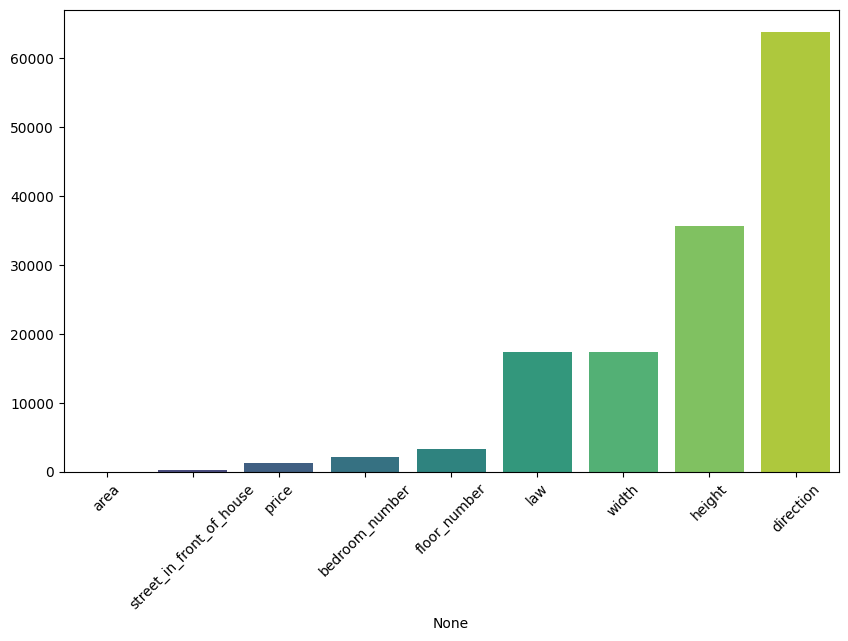

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, hue=missing_values.index, palette='viridis', legend=False)
plt.xticks(rotation = 45)
plt.show()

### 5.2. Quyết định xử lý cho cột `direction`

In [28]:
df['direction'].isna().sum()/len(df['direction'])

np.float64(0.8440425194351896)

### 5.3. Kết quả xử lý Missing Values

* **Loại bỏ:** Cột `direction` bị xóa do tỷ lệ thiếu lên tới **~84%**, không đủ thông tin để nội suy.
* **Lọc mẫu:** Loại bỏ các dòng có `price` là `nan` vì đây là biến mục tiêu (**target variable**).

In [29]:
df.drop('direction', axis = 1, inplace = True)
#bỏ cả các price bị nan vì sau này đây sẽ là cột target
df = df[df.price.notna()]

## Phần 6: Phân tách nhóm thuộc tính

Chia dữ liệu thành hai nhóm chính để áp dụng các kỹ thuật xử lý chuyên biệt:

* **Numerical Features:** Các biến số như `price`, `area`, `width`...
* **Categorical Features:** Các biến phân loại như `type`, `city`, `district`...

In [30]:
num_features = df.select_dtypes(exclude=['object', 'bool']).copy()
cate_features = df.select_dtypes(include=['object', 'bool']).copy()
print(num_features.columns)
print(cate_features.columns)

Index(['price', 'area', 'floor_number', 'bedroom_number',
       'street_in_front_of_house', 'width', 'height'],
      dtype='object')
Index(['is_dinning_room', 'is_kitchen', 'is_terrace', 'is_car_pack',
       'is_owner', 'type', 'law', 'city', 'district'],
      dtype='object')


## Phần 7: Trực quan hóa phân phối dữ liệu

### 7.1. Sử dụng Histogram và KDE Plot

Thực hiện vẽ phân phối cho `num_features` nhằm:

* Quan sát **độ lệch** (skewness) của dữ liệu.
* Phát hiện sơ bộ các **giá trị ngoại lai** (outliers).
* Đánh giá xem dữ liệu có tuân theo **phân phối chuẩn** hay không.

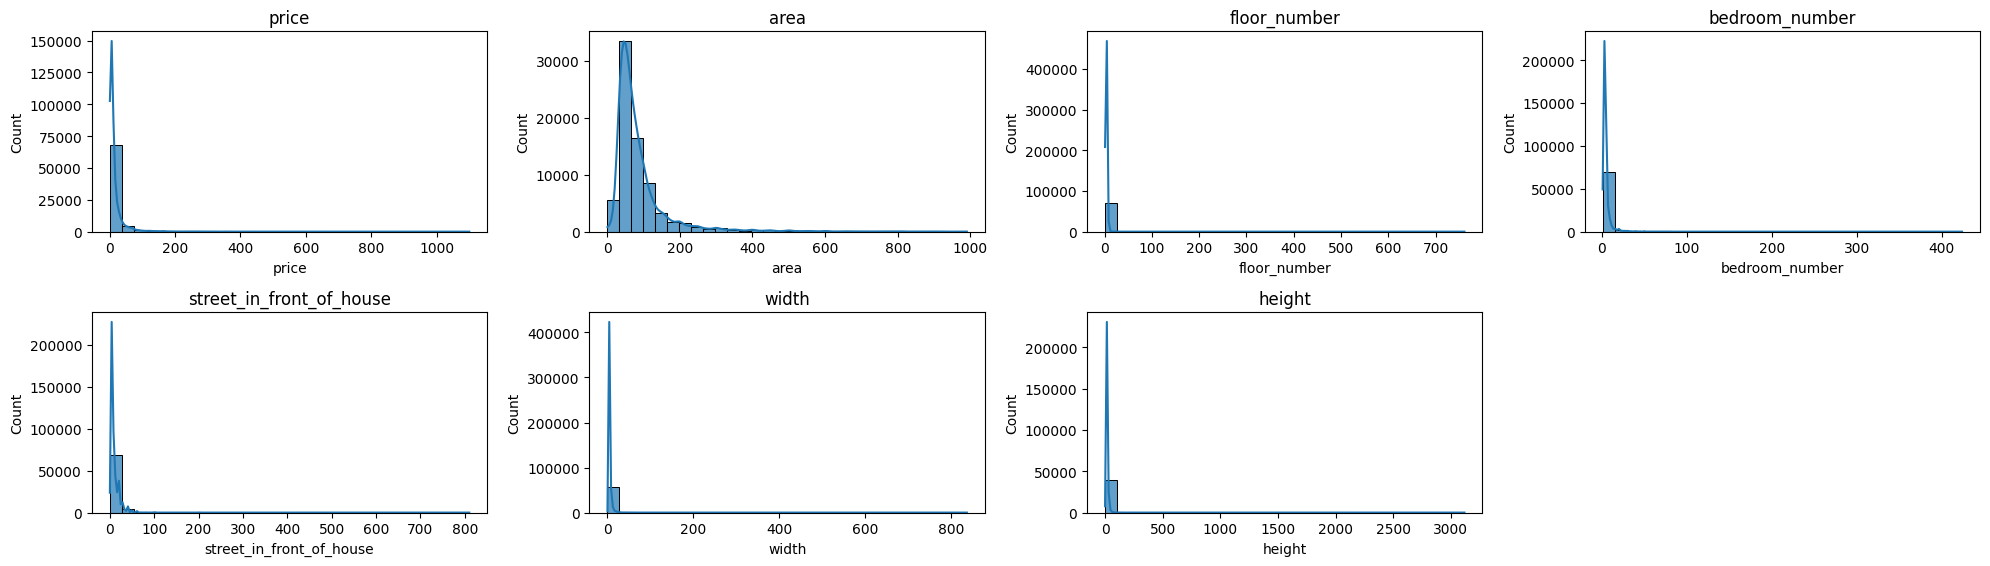

In [31]:
plt.figure(figsize=(20, 25))

for i, col in enumerate(num_features.columns):

    plt.subplot(9, 4, i + 1)

    sns.histplot(
    num_features[col].dropna(),
    bins=30,
    kde=True,
    alpha=0.7,

)

    plt.title(col)

plt.tight_layout()

### 7.2. Nhận xét về phân phối thô

Biểu đồ **KDE** cho thấy hiện tượng **Extreme Right-Skewed** (Lệch phải cực độ):

* Nguyên nhân: Do lỗi nhập liệu hoặc sự hiện diện của các bất động sản siêu sang.
* Các giá trị bất thường xuất hiện ở: `price`, `area`, `floor_number`.

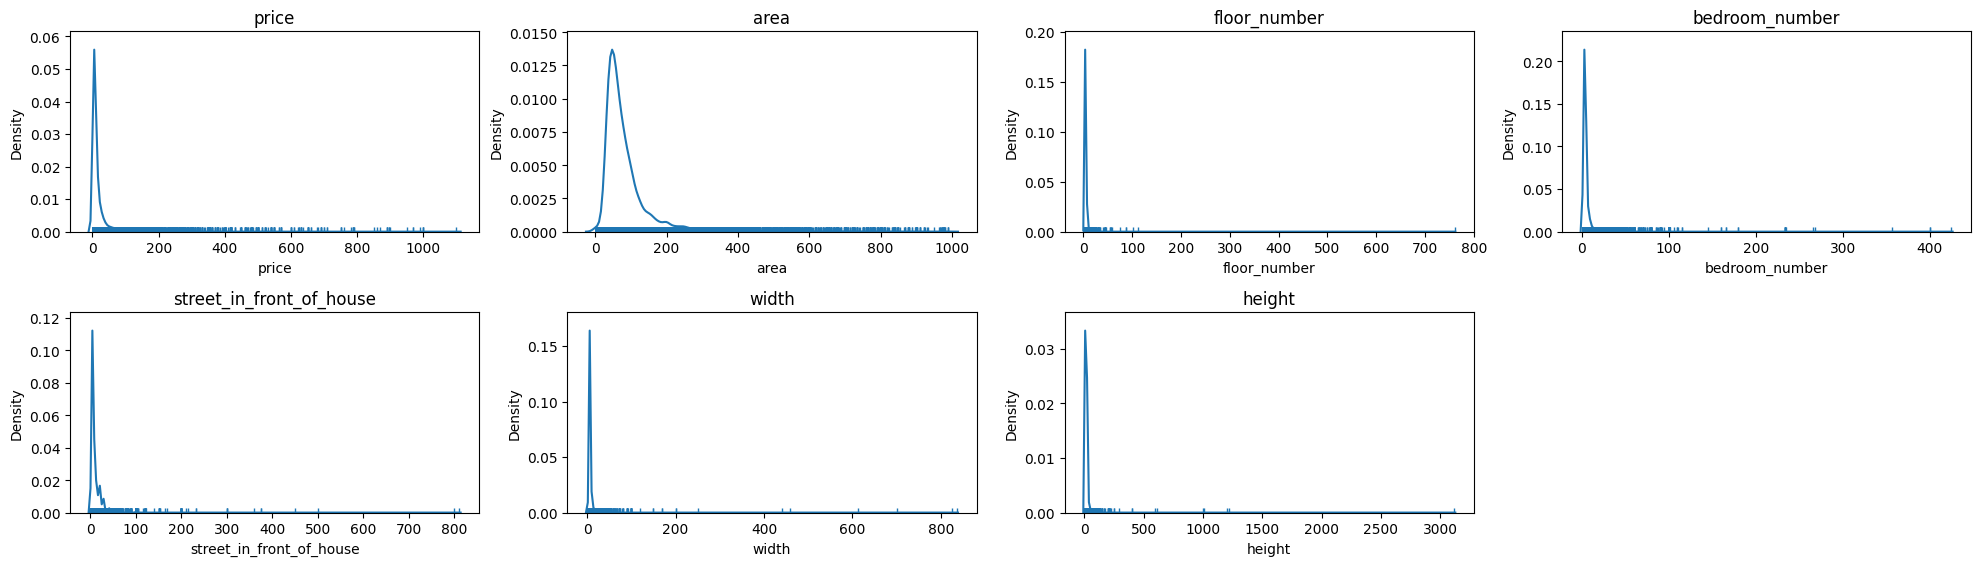

In [32]:
plt.figure(figsize=(20, 25))

for i, col in enumerate(num_features.columns):

    plt.subplot(9, 4, i + 1)

    sns.distplot(
        num_features[col].dropna(),
        hist=False,
        rug=True
    )

    plt.title(col)

plt.tight_layout()

## Phần 8: Xử lý giá trị ngoại lai (Outliers)

### 8.1. Thiết lập ngưỡng nghiệp vụ (Hard Thresholds)

Thay vì dùng các quy tắc thống kê cứng nhắc, chúng ta áp dụng **kiến thức ngành** để lọc bỏ dữ liệu rác:

* **Price:** Loại bỏ các căn > 200 tỷ.
* **Area:** Giới hạn diện tích < 400m2.
* **Phòng ngủ/Tầng:** Giới hạn số lượng < 50 để đảm bảo tính thực tế.

In [33]:
df.drop(df[df.price > 200].index, inplace = True)
df.drop(df[df.area > 400].index, inplace = True)
df.drop(df[df.floor_number > 50].index, inplace = True)
df.drop(df[df.bedroom_number > 50].index, inplace = True)
df.drop(df[df.street_in_front_of_house > 100].index, inplace = True)
df.drop(df[df.width > 100].index, inplace = True)
df.drop(df[df.height > 200].index, inplace = True)

In [34]:
# Tách lại feature sau cleaning
num_features = df.select_dtypes(exclude=['object', 'bool']).copy()
cate_features = df.select_dtypes(include=['object', 'bool']).copy()

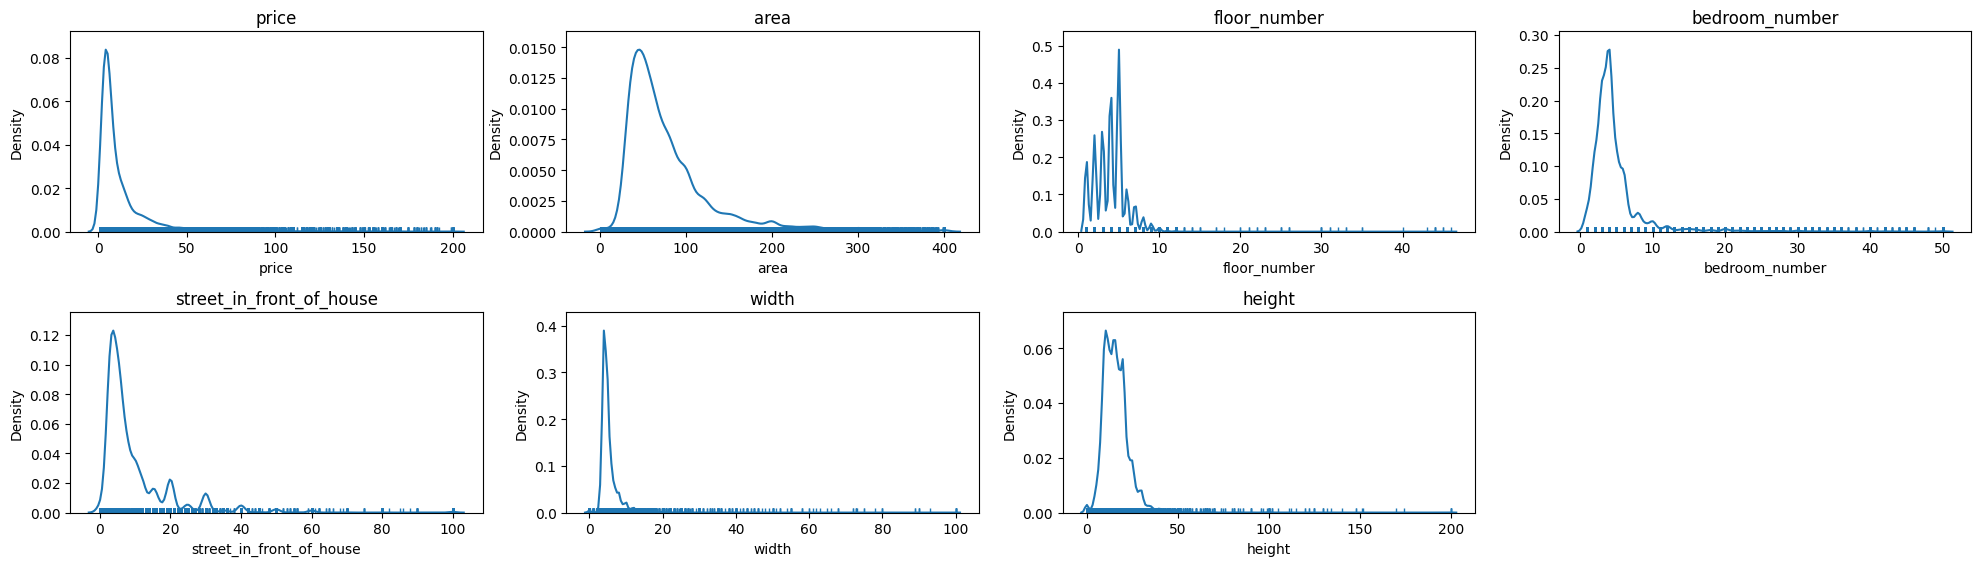

In [35]:
plt.figure(figsize=(20, 25))

for i, col in enumerate(num_features.columns):

    plt.subplot(9, 4, i + 1)

    sns.distplot(
        num_features[col].dropna(),
        hist=False,
        rug=True
    )

    plt.title(col)

plt.tight_layout()

### 8.2. Kiểm tra bằng Boxplot

Sử dụng biểu đồ **Boxplot** để xác định các điểm dữ liệu nằm ngoài khoảng an toàn:

* Xác định **Median** và **IQR**.
* Quan sát trực quan các điểm đen (outliers) còn sót lại sau bước lọc đầu tiên.

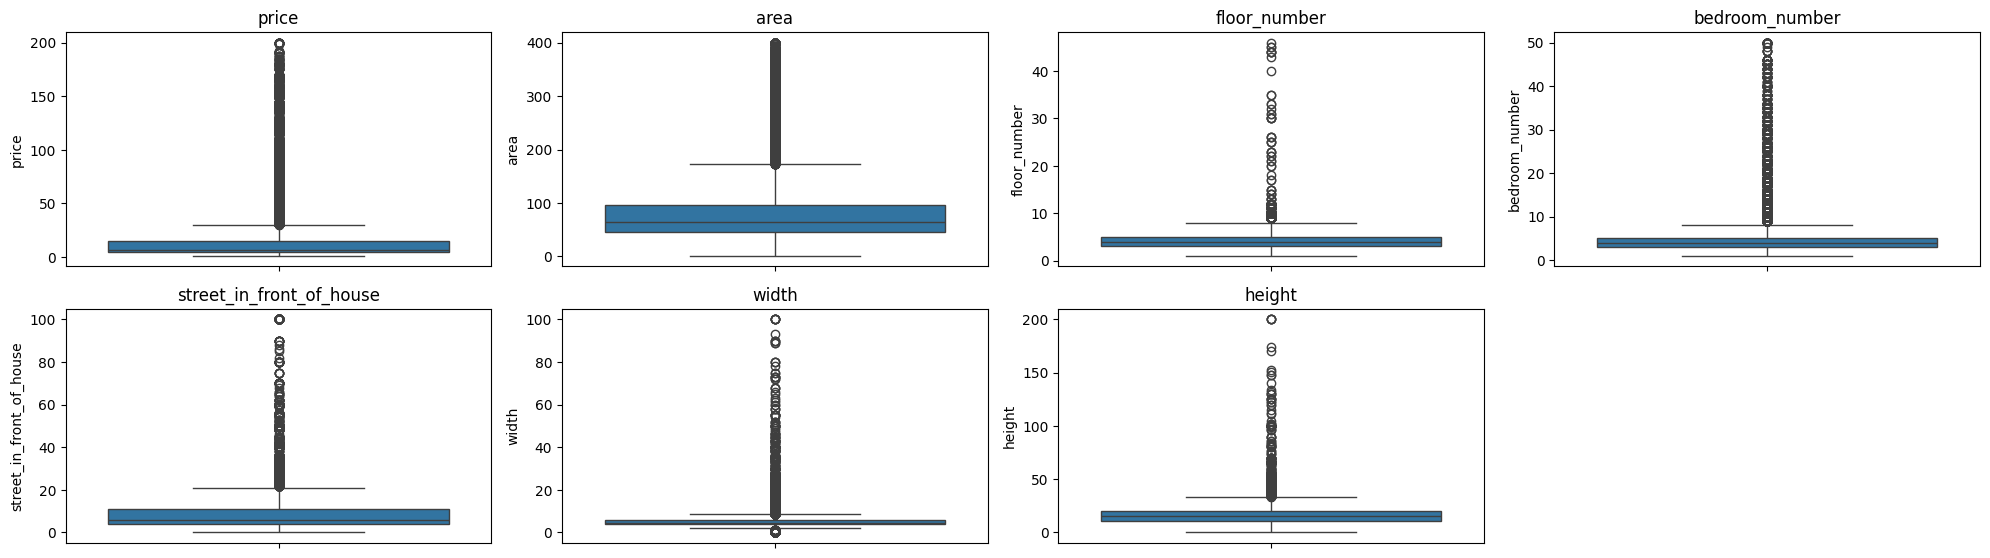

In [36]:
plt.figure(figsize=(20, 25))

for i, col in enumerate(num_features.columns):

    plt.subplot(9, 4, i + 1)

    sns.boxplot(
        y=num_features[col].dropna()
    )

    plt.title(col)

plt.tight_layout()

### 8.3. Tinh chỉnh dữ liệu theo phân khúc mục tiêu

Để mô hình đạt độ chính xác cao cho phân khúc nhà phổ thông, chúng ta áp dụng các ngưỡng chặt chẽ hơn:

* **Giá trị thực tế:** Lọc `price` trong khoảng (0, 15] tỷ đồng.
* **Diện tích chuẩn:** Giới hạn `area` trong khoảng (0, 125] m2.
* **Cấu trúc:** Số tầng và phòng ngủ tối đa là `8`.
* **Kích thước mảnh đất:** `width` từ 2m đến 7m; `height` không quá 30m.
* **Hạ tầng:** `street_in_front_of_house` tối đa 15m.

In [37]:
df.drop(df[df.price <= 0].index, inplace = True)
df.drop(df[df.price > 15].index, inplace = True)

df.drop(df[df.area > 125].index, inplace = True)
df.drop(df[df.area <= 0].index, inplace = True)

df.drop(df[df.floor_number > 8].index, inplace = True)
df.drop(df[df.floor_number <= 0].index, inplace = True)

df.drop(df[df.bedroom_number > 8].index, inplace = True)
df.drop(df[df.bedroom_number < 2].index, inplace = True)

df.drop(df[df.street_in_front_of_house > 15].index, inplace = True)

df.drop(df[df.width > 7].index, inplace = True)
df.drop(df[df.width <= 2].index, inplace = True)

df.drop(df[df.height > 30].index, inplace = True)
df.drop(df[df.height <= 0].index, inplace = True)


In [38]:
# Tách lại feature sau cleaning
num_features = df.select_dtypes(exclude=['object', 'bool']).copy()
cate_features = df.select_dtypes(include=['object', 'bool']).copy()

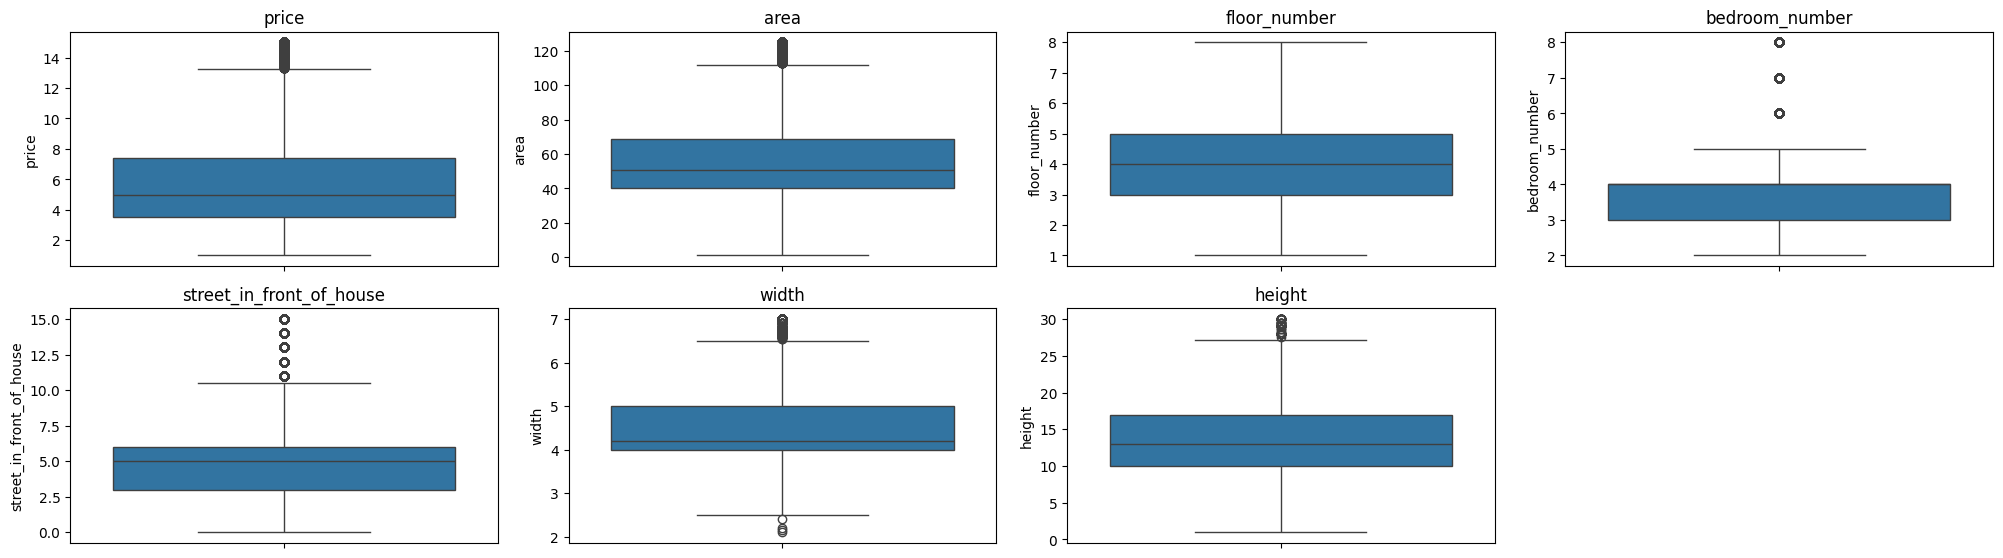

In [39]:
plt.figure(figsize=(20, 25))

for i, col in enumerate(num_features.columns):

    plt.subplot(9, 4, i + 1)

    sns.boxplot(
        y=num_features[col].dropna()
    )

    plt.title(col)

plt.tight_layout()

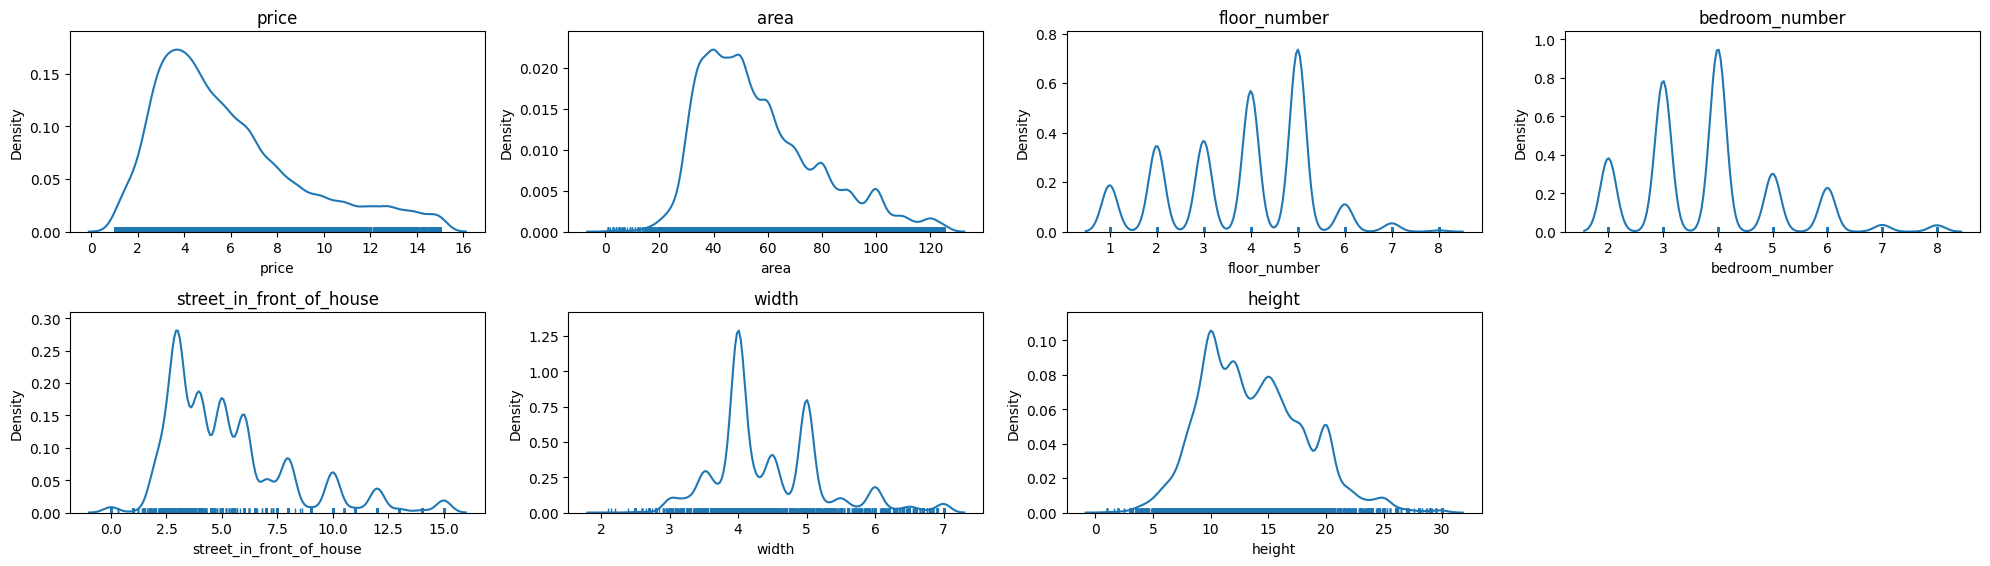

In [40]:
plt.figure(figsize=(20, 25))

for i, col in enumerate(num_features.columns):

    plt.subplot(9, 4, i + 1)

    sns.distplot(
        num_features[col].dropna(),
        hist=False,
        rug=True
    )

    plt.title(col)

plt.tight_layout()

In [41]:
#Kích thước data sau khi loại bỏ outlier
df.shape

(45538, 16)

## Phần 9: Phân tích tương quan

### 9.1. Ma trận tương quan (Correlation Matrix)

Sử dụng **Heatmap** để đo lường mối quan hệ tuyến tính giữa các biến số:

* Xác định các biến có ảnh hưởng mạnh nhất tới `price`.
* Kiểm tra hiện tượng **đa cộng tuyến** (Multicollinearity).

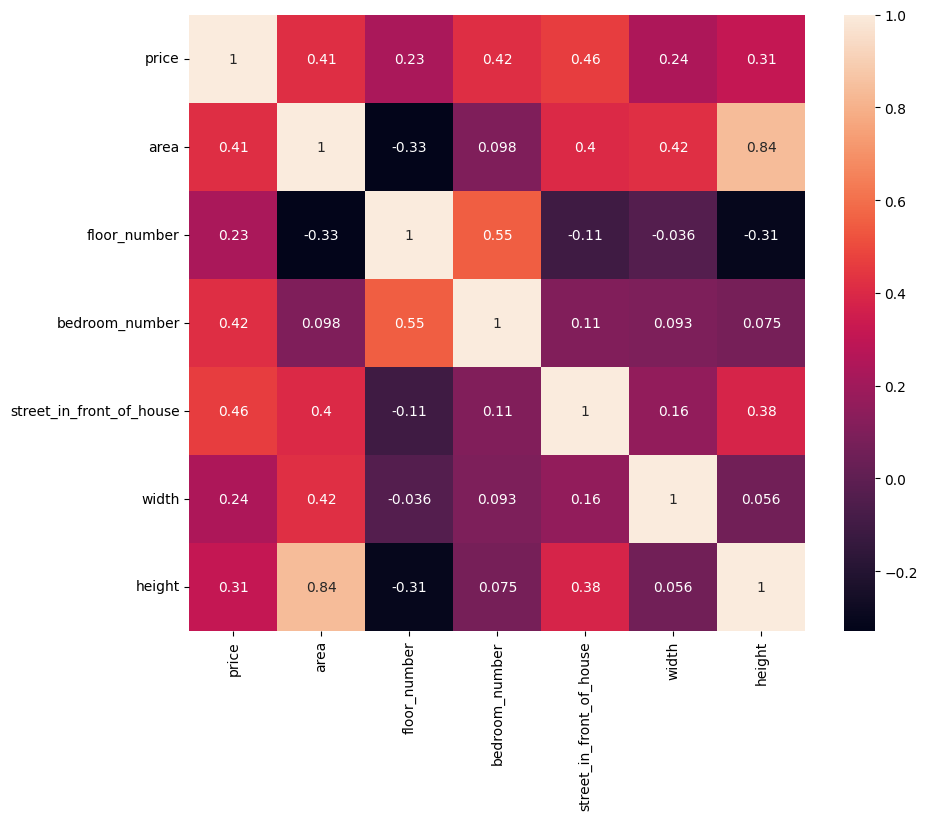

In [42]:
plt.figure(figsize = (10, 8))
sns.heatmap(num_features.corr(), annot = True, square = True)
plt.show()

### 9.2. Xử lý đa cộng tuyến

* Quan sát thấy `height` và `area` có tương quan cực cao (**~0.84**).
* Quyết định: Loại bỏ cột `height` để tránh gây nhiễu và làm mất ổn định mô hình.

In [43]:
df.drop(columns='height', axis =1, inplace = True)

## Phần 10: Phân tích thuộc tính phân loại

### 10.1. Trực quan hóa đặc trưng Categorical

Sử dụng `sns.countplot()` để đánh giá:

* **Mất cân bằng dữ liệu:** Kiểm tra xem có nhóm nào chiếm tỷ lệ quá áp đảo không.
* **Giá trị rác:** Phát hiện các nhóm có quá ít mẫu hoặc sai định dạng chuỗi.

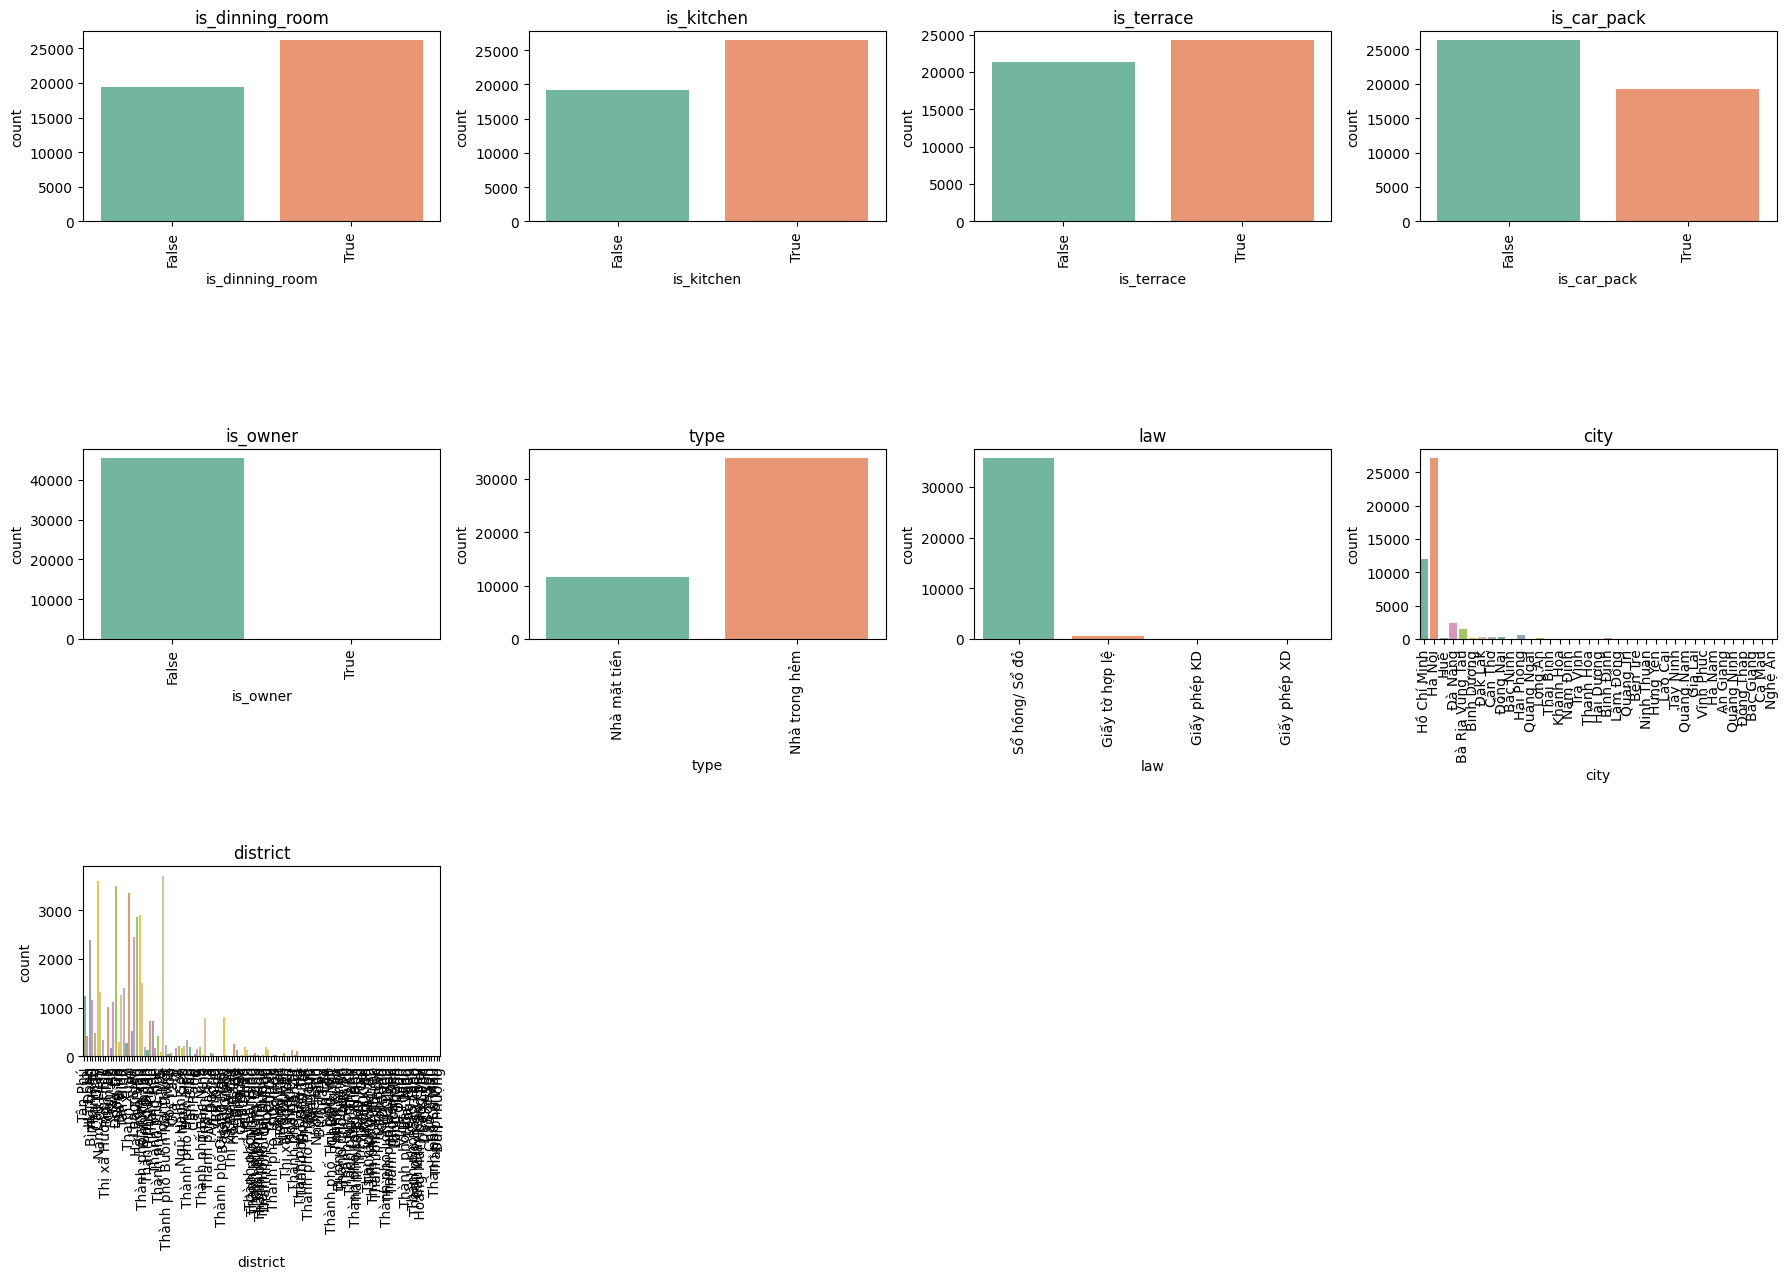

In [44]:
plt.figure(figsize=(18, 40))

for i, col in enumerate(cate_features.columns):
    plt.subplot(10, 4, i + 1)

    sns.countplot(
        x = cate_features[col].dropna(),
        palette = 'Set2'
    )

    plt.xticks(rotation=90)
    plt.title(col)

plt.tight_layout()

### 10.2. Loại bỏ các đặc trưng không mang tính phân hóa

* **Cột `law`:** Đa số là "Sổ hồng/Sổ đỏ", không có khả năng phân biệt giá.
* **Cột `is_owner`:** Gần như toàn bộ là `False`, gây mất cân bằng nghiêm trọng.
* Quyết định: Loại bỏ cả hai để tối ưu hóa mô hình.

In [45]:
df.drop(columns=['is_owner', 'law'], axis=1, inplace=True)


In [46]:
df['city']

,city
1,Hồ Chí Minh
2,Hồ Chí Minh
3,Hà Nội
4,Hà Nội
5,Hồ Chí Minh
...,...
75628,Hà Nội
75629,Hà Nội
75630,Hà Nội
75631,Hà Nội


## Phần 11: Feature Engineering (Kỹ nghệ đặc trưng)

### 11.1. Lọc dữ liệu theo khu vực trọng điểm

* Chỉ giữ lại các bản ghi thuộc **Hà Nội** và **Hồ Chí Minh**.
* Lý do: Đây là hai thị trường có lượng dữ liệu lớn nhất và có quy luật giá ổn định hơn các tỉnh lẻ.

In [47]:
df = df[df['city'].isin(['Hà Nội', 'Hồ Chí Minh'])]

In [48]:
cate_features = df.select_dtypes(include=['object', 'bool'])

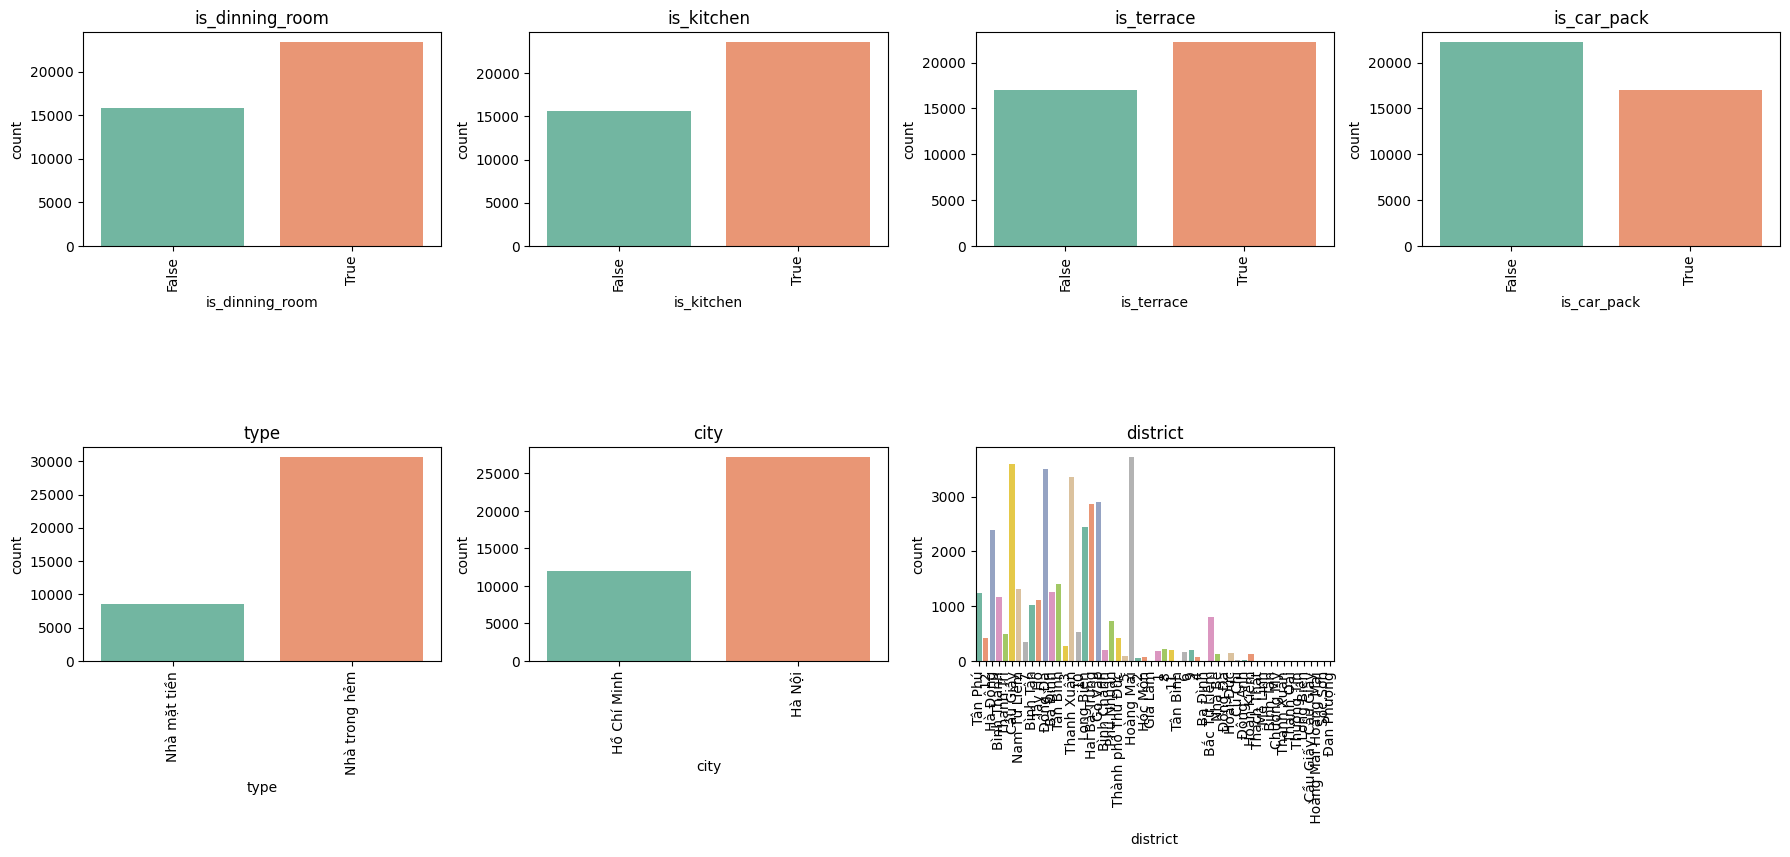

In [49]:
plt.figure(figsize=(18, 40))

for i, col in enumerate(cate_features.columns):
    plt.subplot(10, 4, i + 1)

    sns.countplot(
        x = cate_features[col].dropna(),
        palette = 'Set2'
    )

    plt.xticks(rotation=90)
    plt.title(col)

plt.tight_layout()

### 11.2. Phân loại khu vực Nội thành và Ngoại thành

Biến đổi cột `district` thành đặc trưng nhị phân:

* **Mục tiêu:** Giảm số lượng category (từ hàng chục quận xuống còn 2 nhóm).
* **Ý nghĩa:** Tận dụng quy luật giá trị đất tại trung tâm luôn cao hơn vùng ven.
* **Kỹ thuật:** Sử dụng danh sách `urban_area` để định nghĩa các quận nội thành.

In [50]:
df['district'].value_counts()

,count
district,
Hoàng Mai,3715
Cầu Giấy,3601
Đống Đa,3501
Thanh Xuân,3349
Gò Vấp,2901
Hai Bà Trưng,2855
Long Biên,2445
Hà Đông,2382
Tân Bình,1406


### 11.3. Nhận xét về chất lượng dữ liệu Quận/Huyện

Qua thống kê `value_counts()`, ta nhận thấy 3 vấn đề cần làm sạch:

* **Lỗi khoảng trắng:** Ví dụ `' Tân Bình'`.
* **Lỗi lặp từ:** Ví dụ `' Cầu Giấy Cầu Giấy'`.
* **Lỗi định dạng số:** Các quận tại TP.HCM thường được ghi bằng số (`'10'`, `'12'`).

In [51]:
urban_area = [
    'Đống Đa', 'Cầu Giấy', 'Thanh Xuân', 'Hoàng Mai',
    'Hai Bà Trưng', 'Gò Vấp', 'Tân Bình', 'Ba Đình',
    'Tây Hồ', 'Tân Phú', 'Bình Thạnh', 'Phú Nhuận',
    '10', '1', '3', '7', '11', '8', '6', '5', '2', '4',
    'Hoàn Kiếm'
]

df['district'] = df['district'].str.strip()

df['district'] = df['district'].replace({
    'Cầu Giấy Cầu Giấy': 'Cầu Giấy',
    'Hoàng Mai Hoàng Mai': 'Hoàng Mai'
})

df['district'] = np.where(
    df['district'].isin(urban_area),
    'Nội thành',
    'Ngoại thành'
)

### 11.4. Mã hóa nhị phân (Binary Encoding)

Thực hiện chuyển đổi các biến phân loại sang định dạng số `0/1`:

* **Thành phố (`city`):** `Hà Nội` = 1, `Hồ Chí Minh` = 0.
* **Loại nhà (`type`):** `Nhà mặt tiền` = 1, `Nhà trong hẻm` = 0.

In [52]:
df['city'] = np.where(df['city'] == 'Hà Nội', 1, 0)
df['type'] = np.where(df['type'] == 'Nhà mặt tiền', 1, 0)

In [53]:
cate_features = df.select_dtypes(include=['object', 'bool']).copy()


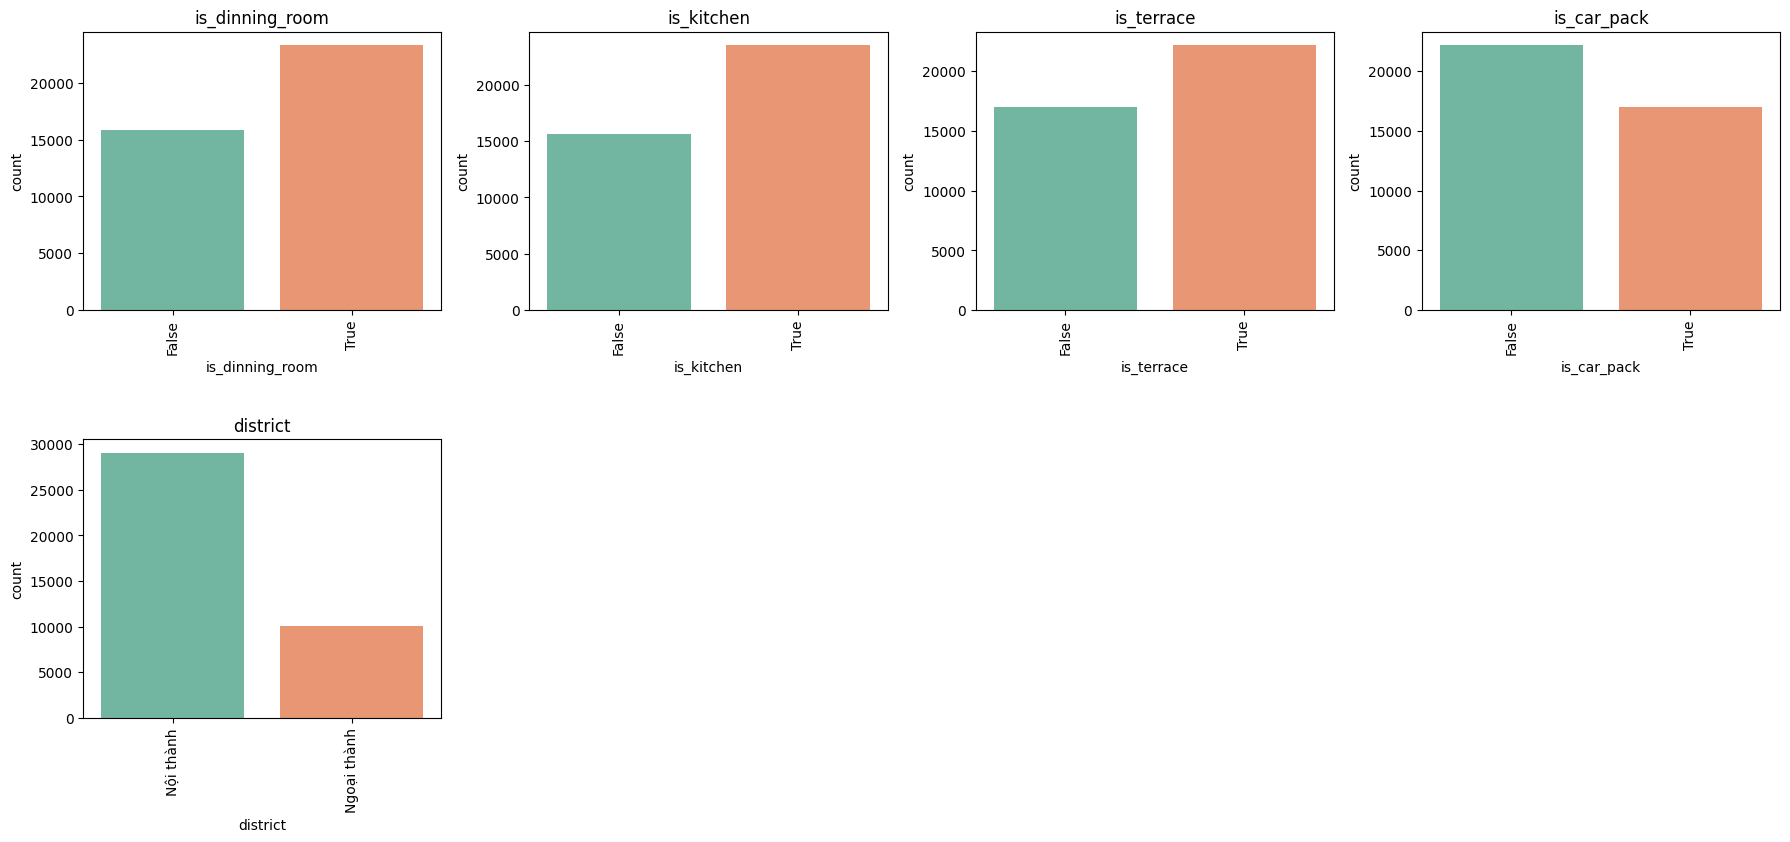

In [54]:
plt.figure(figsize=(18, 40))

for i, col in enumerate(cate_features.columns):
    plt.subplot(10, 4, i + 1)

    sns.countplot(
        x = cate_features[col].dropna(),
        palette = 'Set2'
    )

    plt.xticks(rotation=90)
    plt.title(col)

plt.tight_layout()

### 11.5. Mã hóa khu vực cư trú

* Chuyển đổi cột `district` sau khi đã gom nhóm:
* `Nội thành` = 1, `Ngoại thành` = 0.

In [55]:
df['district'] = np.where(df['district'] == 'Nội thành', 1, 0)

### 11.6. Chuyển đổi các biến logic (Boolean)

* Chuyển các cột tiện ích (`is_kitchen`, `is_terrace`...) sang kiểu `int`.
* Giá trị `True` tương ứng với `1`, `False` tương ứng với `0`.

In [56]:
bool_cols = [
    'is_dinning_room',
    'is_kitchen',
    'is_terrace',
    'is_car_pack'
]

df[bool_cols] = df[bool_cols].astype(int)


In [57]:
num_features = df.select_dtypes(exclude=['object', 'bool']).copy()


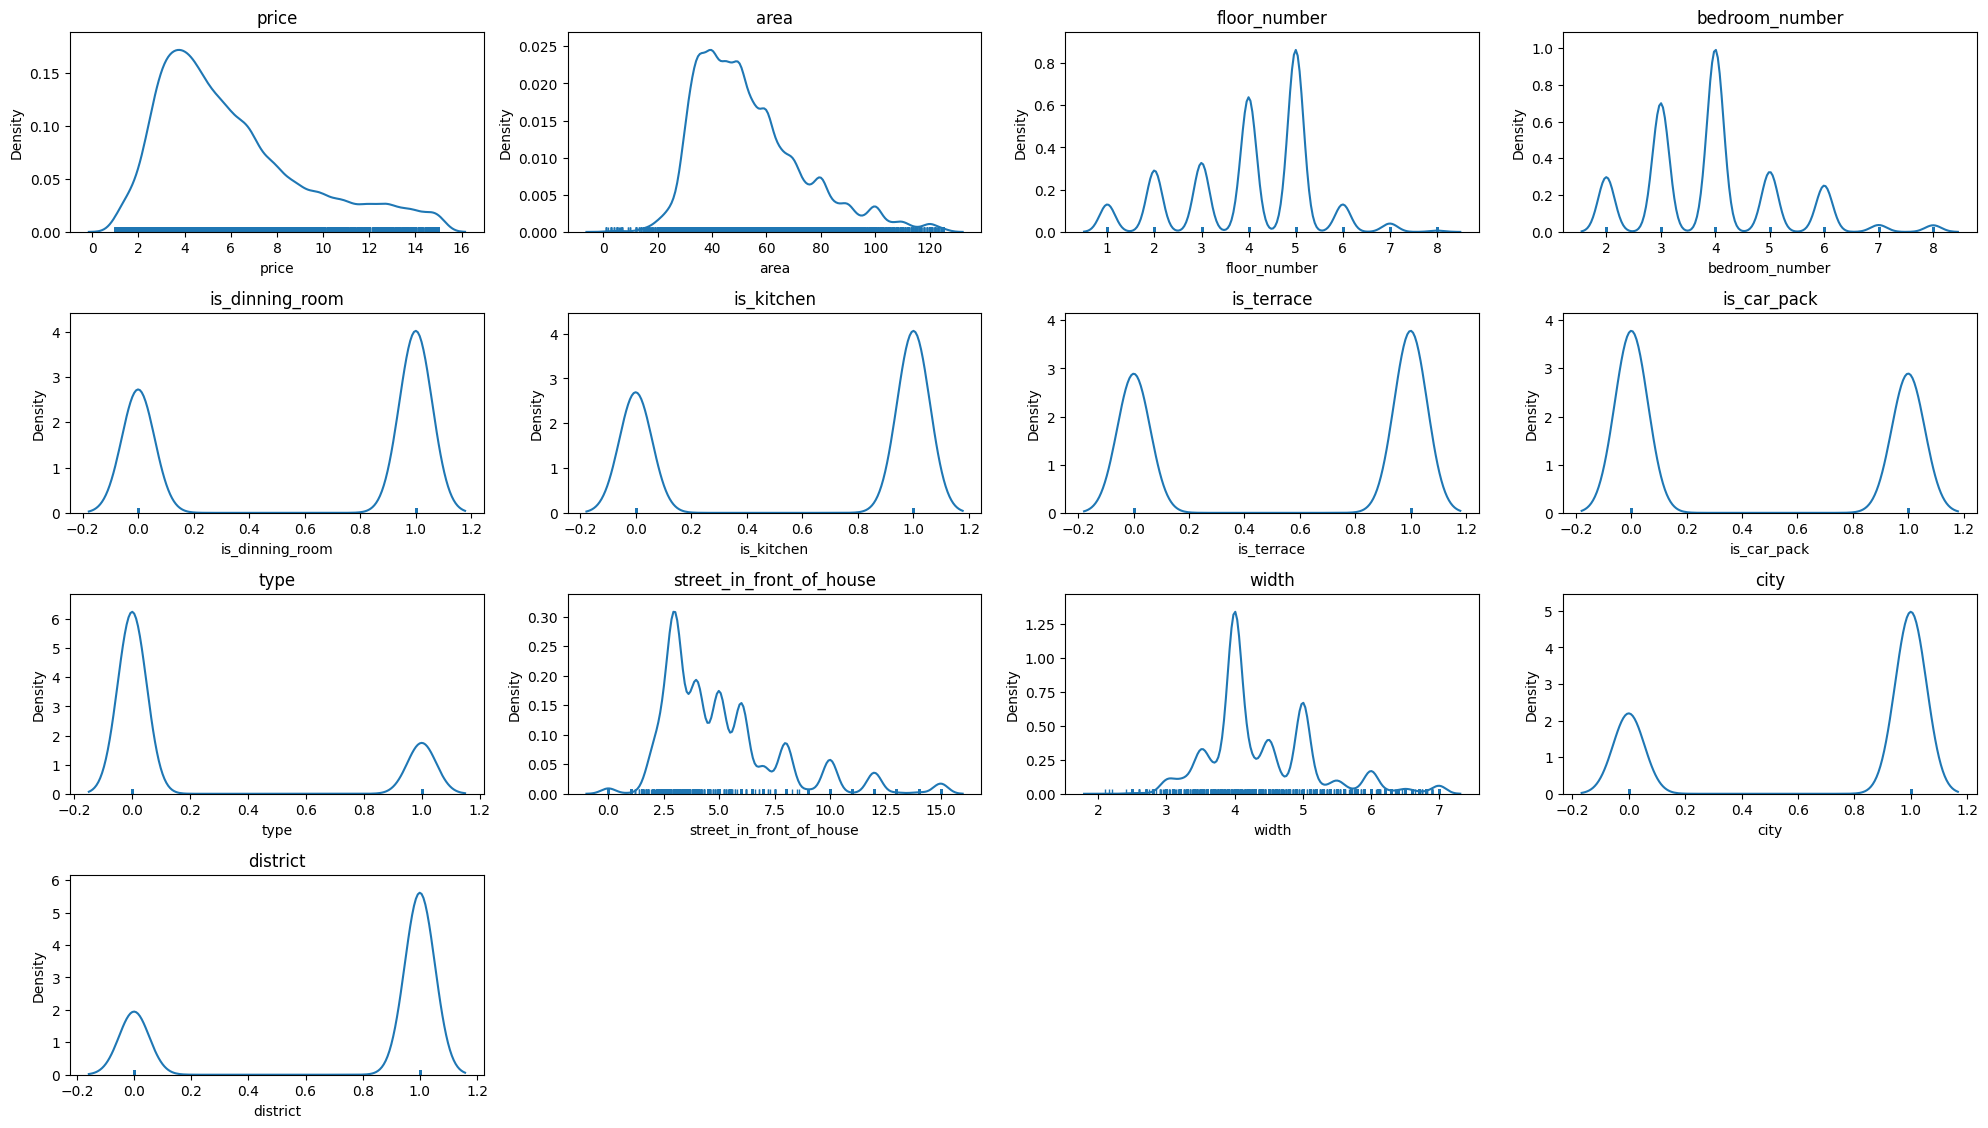

In [58]:
plt.figure(figsize=(20, 25))

for i, col in enumerate(num_features.columns):

    plt.subplot(9, 4, i + 1)

    sns.distplot(
        num_features[col].dropna(),
        hist=False,
        rug=True
    )

    plt.title(col)

plt.tight_layout()

## Phần 12: Log Transformation (Biến đổi Logarit)

### 12.1. Phân tích sự cần thiết của biến đổi Log

Dữ liệu thực tế cho thấy các biến `price`, `area`, `width` có độ chênh lệch cực lớn. Việc sử dụng nguyên bản sẽ làm mô hình bị nhiễu bởi các giá trị cực đại.

### 12.2. Áp dụng kỹ thuật `log1p`

Sử dụng công thức $x' = \ln(x + 1)$ cho các cột:

* `price`, `area`, `width`.
* `floor_number`, `bedroom_number`.
* `street_in_front_of_house`.

**Lợi ích:** Đưa phân phối về gần **dạng chuẩn**, giảm ảnh hưởng của Outliers và cải thiện độ hội tụ của thuật toán.

In [59]:
log_columns = [
    'price',
    'area',
    'width',
    'floor_number',
    'bedroom_number',
    'street_in_front_of_house'
]

for col in log_columns:
    df[col] = np.log1p(df[col])

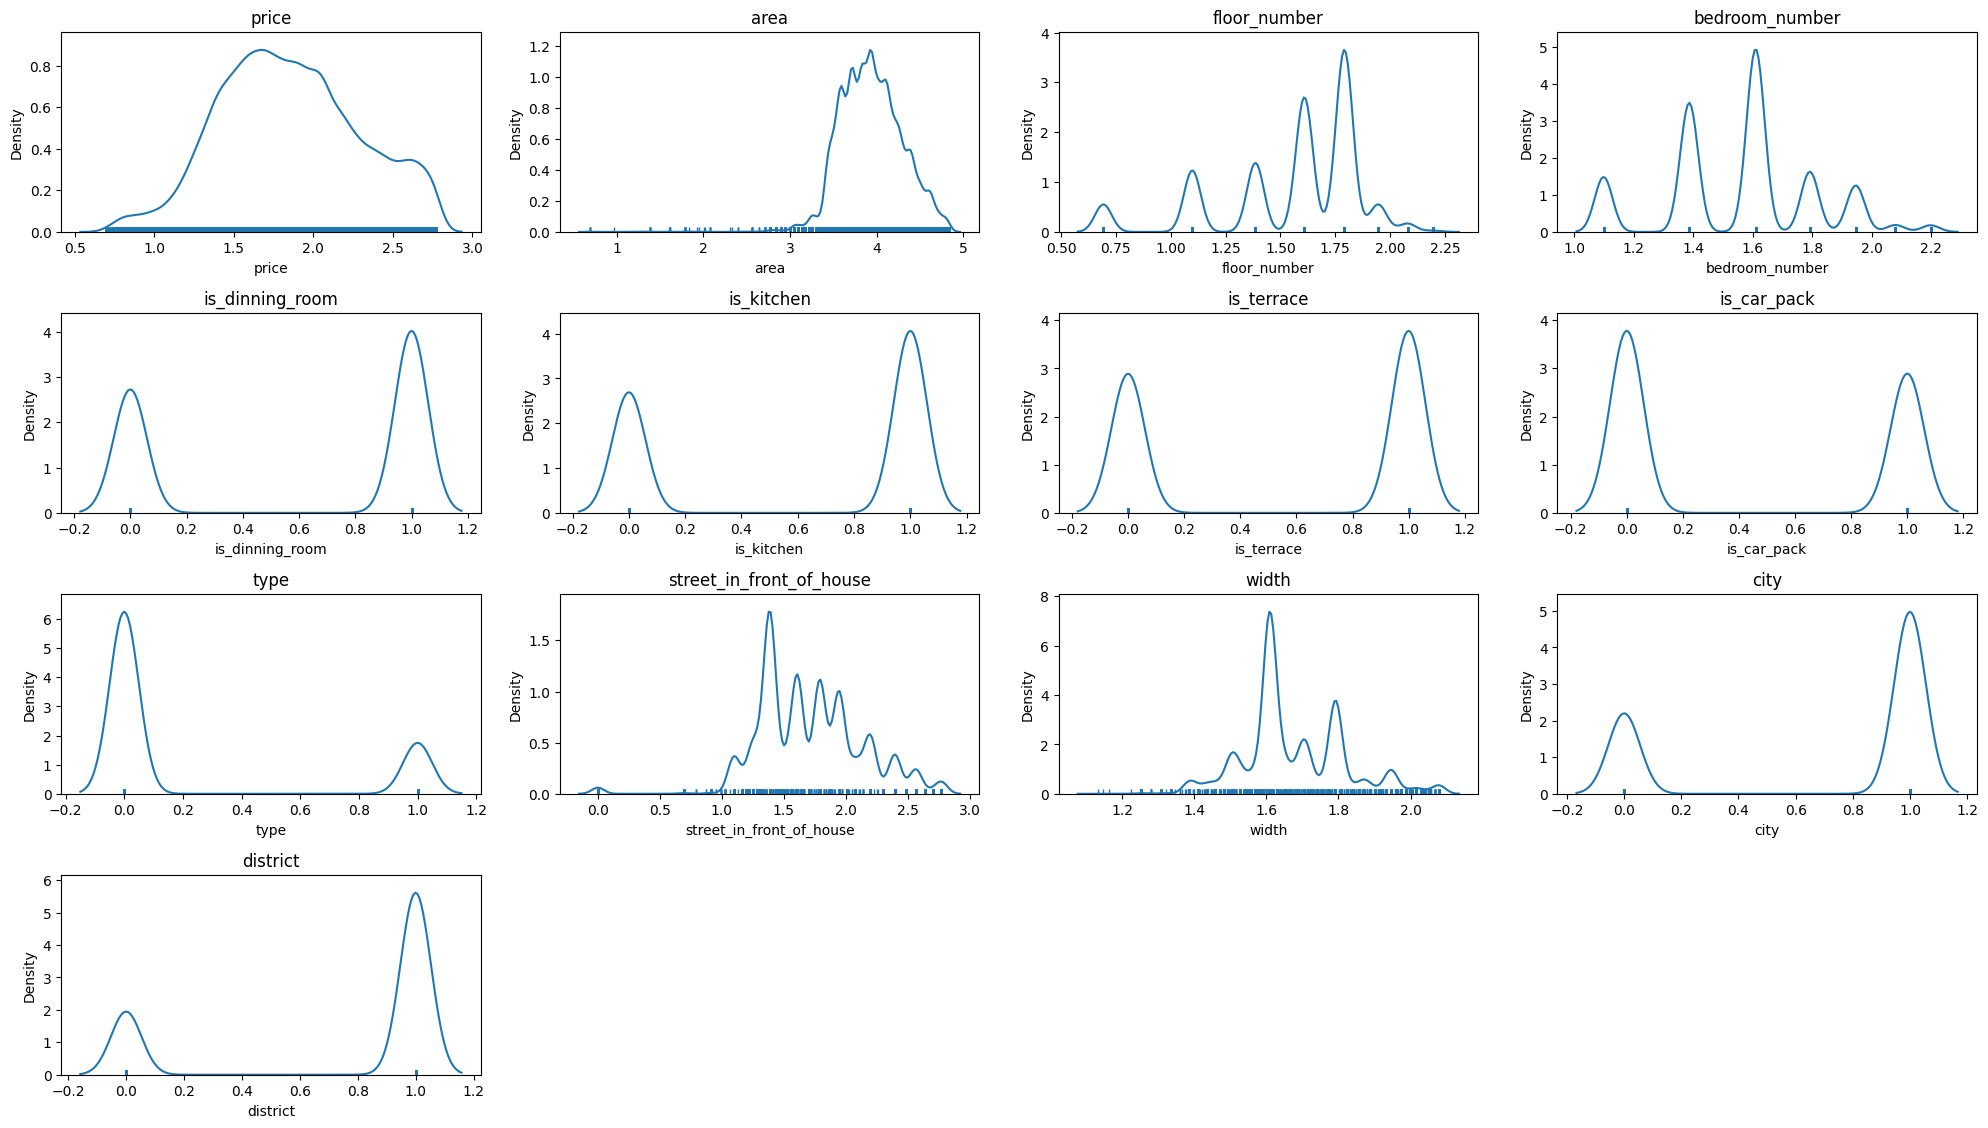

In [60]:
num_features = df.select_dtypes(exclude=['object', 'bool']).copy()
plt.figure(figsize=(20, 25))

for i, col in enumerate(num_features.columns):

    plt.subplot(9, 4, i + 1)

    sns.distplot(
        num_features[col].dropna(),
        hist=False,
        rug=True
    )

    plt.title(col)

plt.tight_layout()

## Phần 13: Kiểm tra kích thước dữ liệu cuối cùng

Sau khi hoàn tất toàn bộ quy trình làm sạch và kỹ nghệ đặc trưng, chúng ta kiểm tra lại `df.shape` để đảm bảo lượng dữ liệu còn lại đủ lớn để huấn luyện mô hình (Kỳ vọng khoảng > 30,000 mẫu).

In [61]:
df.shape

(39160, 13)

## Phần 14: Phân tích giá nhà trung bình theo đặc trưng

### 14.1. Lọc các đặc trưng rời rạc

* Để trực quan hóa bằng biểu đồ cột, chúng ta loại bỏ các biến liên tục như `area`, `width`.
* Chỉ tập trung vào các biến phân loại hoặc số nguyên có dải giá trị hẹp để quan sát **giá trị trung bình**.

### 14.2. Trực quan hóa mối quan hệ biến mục tiêu

* Vẽ biểu đồ cột (`plt.bar`) cho từng đặc trưng đối với `price`.
* Ghi chú giá trị trung bình trên đầu mỗi cột để dễ so sánh.

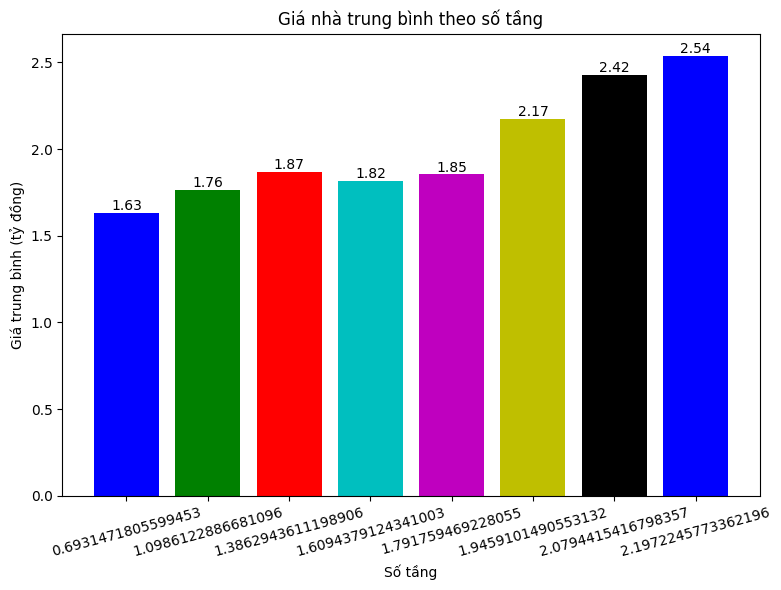

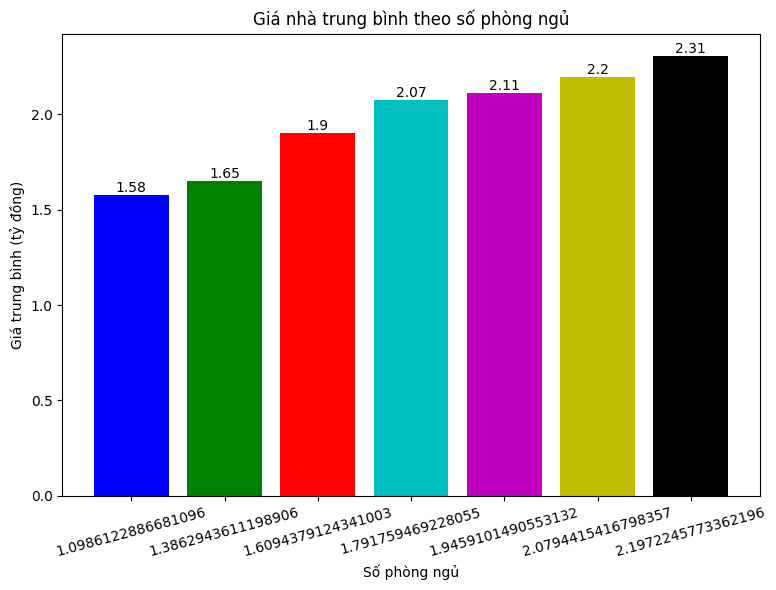

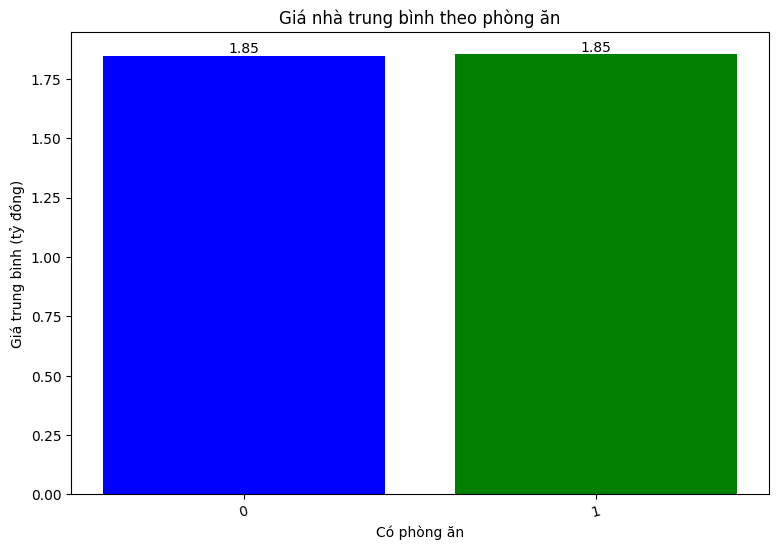

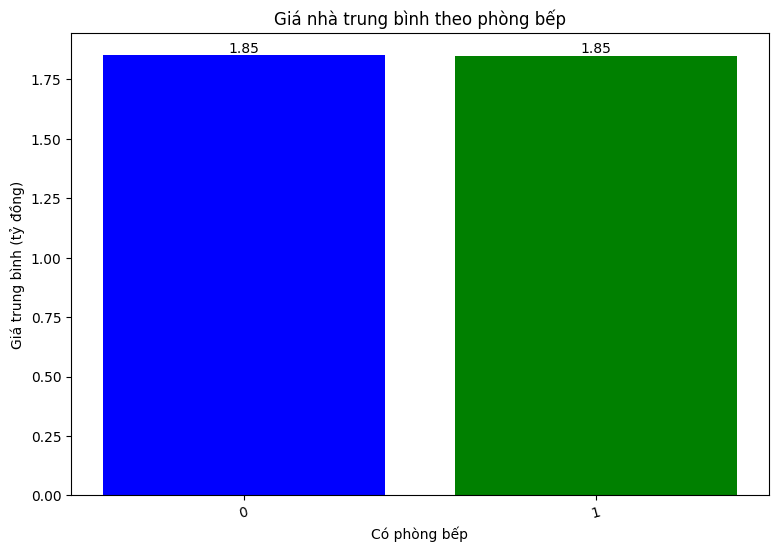

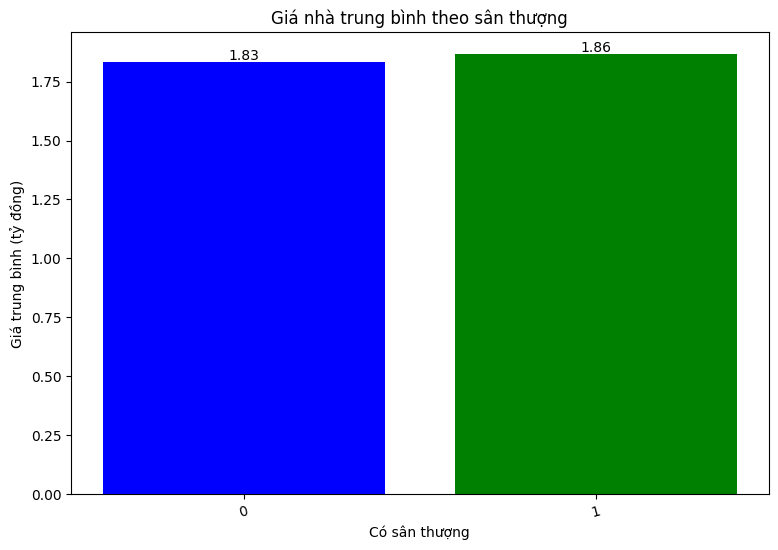

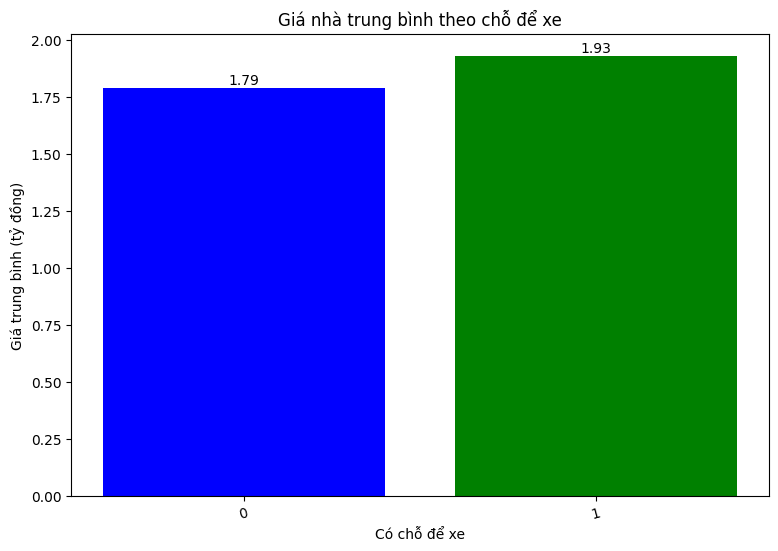

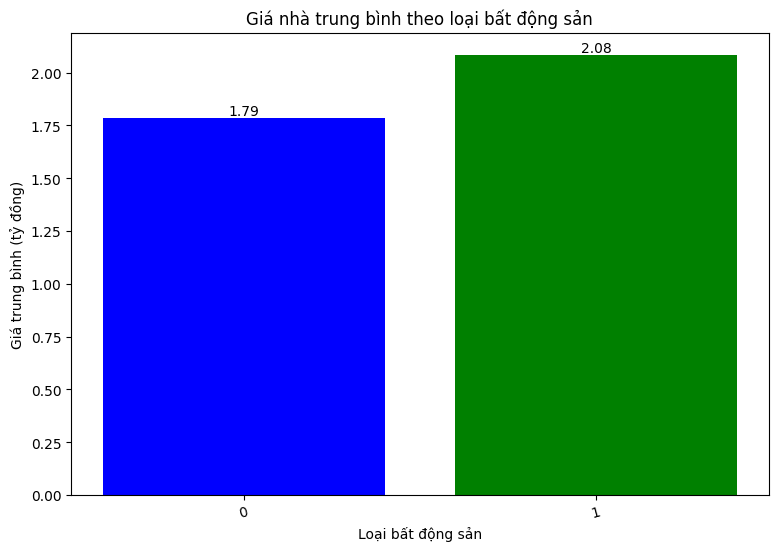

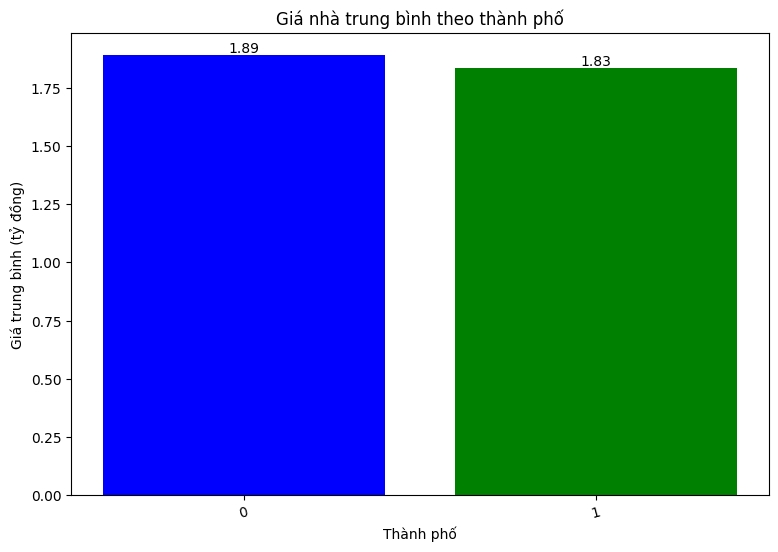

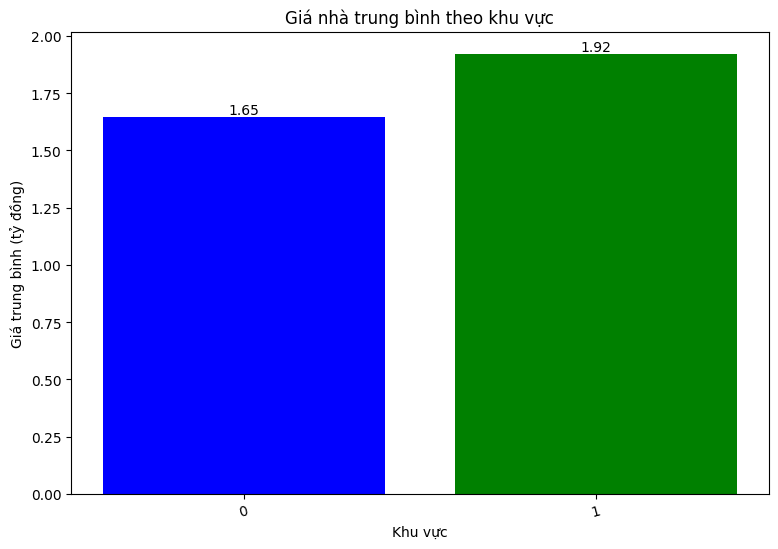

In [62]:
feature_df = df.drop(
    columns=[
        'price',
        'area',
        'street_in_front_of_house',
        'width'
    ]
)

feature_names = feature_df.columns.tolist()

labels = [
    'Số tầng',
    'Số phòng ngủ',
    'Có phòng ăn',
    'Có phòng bếp',
    'Có sân thượng',
    'Có chỗ để xe',
    'Loại bất động sản',
    'Thành phố',
    'Khu vực'
]

titles = [
    'Giá nhà trung bình theo số tầng',
    'Giá nhà trung bình theo số phòng ngủ',
    'Giá nhà trung bình theo phòng ăn',
    'Giá nhà trung bình theo phòng bếp',
    'Giá nhà trung bình theo sân thượng',
    'Giá nhà trung bình theo chỗ để xe',
    'Giá nhà trung bình theo loại bất động sản',
    'Giá nhà trung bình theo thành phố',
    'Giá nhà trung bình theo khu vực'
]
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
for idx, col in enumerate(feature_names):

    # Tính mean theo từng nhóm
    grouped_data = (
        df.groupby(col)['price']
        .mean()
        .sort_index()
    )

    x_values = grouped_data.index.astype(str)
    y_values = grouped_data.values

    plt.figure(figsize=(9, 6))

    bars = plt.bar(
        x_values,
        y_values,
        color=colors[:len(x_values)]
    )

    # Hiển thị giá trị
    for bar in bars:

        y = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            y,
            round(y, 2),
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.xlabel(labels[idx])
    plt.ylabel('Giá trung bình (tỷ đồng)')
    plt.title(titles[idx])

    plt.xticks(rotation=15)

    plt.show()

## Phần 15: Nhận xét tổng quan và kết luận

### 15.1. Các yếu tố quyết định giá bất động sản

* **Vị trí (Nội thành vs Ngoại thành):** Là yếu tố hàng đầu tạo nên sự khác biệt về giá.
* **Loại hình:** Nhà mặt tiền có giá trị thương mại vượt trội so với nhà trong hẻm.
* **Tiện ích:** Các căn có **chỗ để xe ô tô** thường nằm trong phân khúc giá cao hơn hẳn.

### 15.2. Cấu trúc và diện tích

* Giá nhà tỷ lệ thuận với quy mô (số tầng, phòng ngủ) nhưng có xu hướng bão hòa ở các căn có quy mô quá lớn trong cùng một diện tích đất.

## Phần 16: Lưu trữ dữ liệu sạch

* Xuất kết quả cuối cùng ra file `clean_housepredict_data.csv`.
* Dữ liệu này đã sẵn sàng để đưa vào các thuật toán **Machine Learning** (Regression).

In [63]:
df.to_csv('clean_housepredict_data.csv', index=False)